In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("../data/raw/superstore.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [17]:
features = df[
    [
        "Quantity",
        "Discount",
        "Shipping Days",
        "Category",
        "Sub-Category",
        "Region",
        "Segment",
        "Ship Mode"
    ]
]

features = pd.get_dummies(
    features,
    drop_first=True
)

target = df["Sales"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 53.85,-341.42, -1.71,..., -12.77, 0.16, 6.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['Quantity','Discount','Shipping Days',...,'Ship Mode_Same Day', 'Ship Mode_Second Class','Ship Mode_Standard Class']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,233.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)


In [20]:
predictions = model.predict(X_test)

In [21]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MODEL PERFORMANCE
MAE  : 226.31
MSE  : 480704.16
RMSE : 693.33
R²   : 0.1862


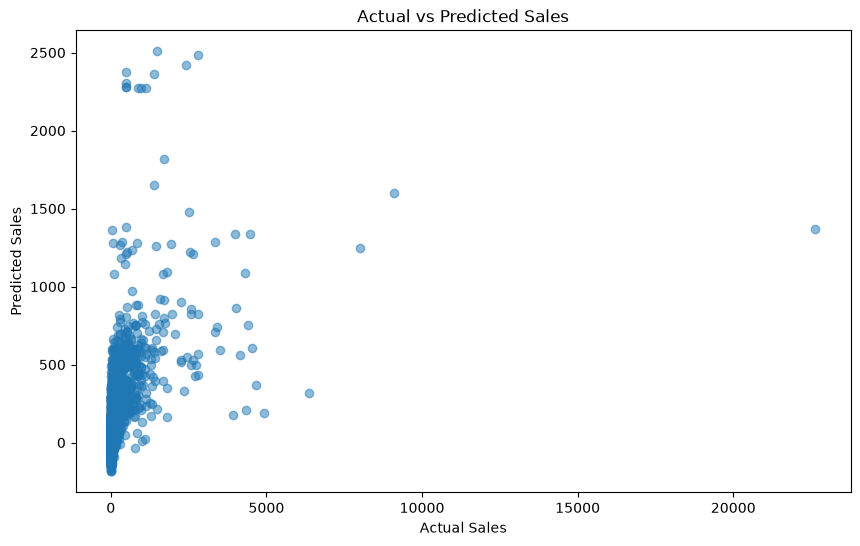

In [22]:
plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [23]:
coefficients = pd.DataFrame({
    "Feature": features.columns,
    "Coefficient": model.coef_
})

print(coefficients)

                     Feature  Coefficient
0                   Quantity    53.848182
1                   Discount  -341.422683
2              Shipping Days    -1.709227
3   Category_Office Supplies  -224.519931
4        Category_Technology  -169.503747
5    Sub-Category_Appliances   111.285460
6           Sub-Category_Art  -123.208914
7       Sub-Category_Binders    69.931180
8     Sub-Category_Bookcases   176.874552
9        Sub-Category_Chairs   161.496204
10      Sub-Category_Copiers  2224.032028
11    Sub-Category_Envelopes   -85.597542
12    Sub-Category_Fasteners  -162.452993
13  Sub-Category_Furnishings  -262.069897
14       Sub-Category_Labels  -123.876482
15     Sub-Category_Machines  1179.468761
16        Sub-Category_Paper   -98.969245
17       Sub-Category_Phones   180.868104
18      Sub-Category_Storage   111.140956
19     Sub-Category_Supplies    77.227650
20       Sub-Category_Tables   317.722819
21               Region_East   -16.425250
22              Region_South   -25

# Linear Regression Model

## Objective

Predict retail sales using:

- Quantity
- Discount
- Shipping Days

## Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The model provides a simple baseline for predicting sales from operational features.

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [26]:
rf_predictions = rf_model.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)

print(f"MAE  : {rf_mae:.2f}")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

RANDOM FOREST PERFORMANCE
MAE  : 214.30
MSE  : 484885.15
RMSE : 696.34
R²   : 0.1791


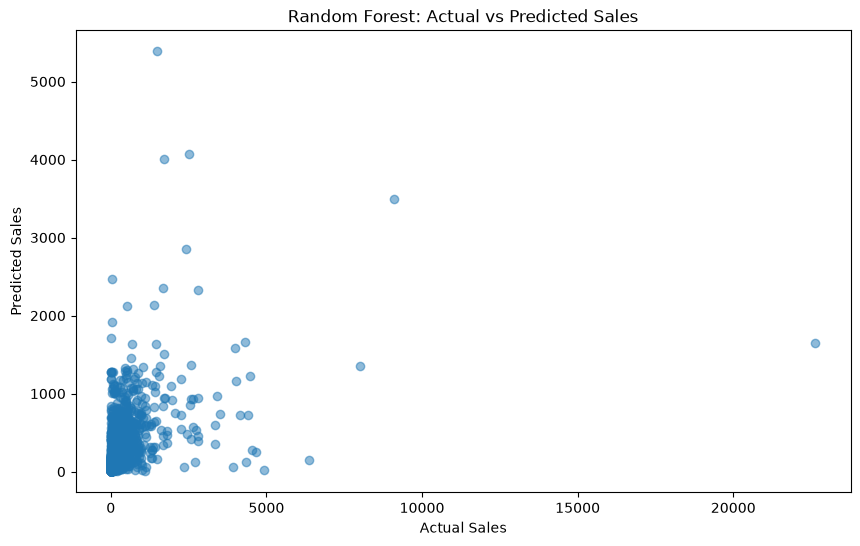

In [29]:
plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Random Forest: Actual vs Predicted Sales")

plt.show()

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,226.308095,693.328320,0.186212
1,Random Forest,214.295678,696.336948,0.179134


In [31]:
importance = pd.DataFrame({
    "Feature": features.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,Quantity,0.221807
2,Shipping Days,0.155453
10,Sub-Category_Copiers,0.109997
1,Discount,0.100134
24,Segment_Corporate,0.061220
15,Sub-Category_Machines,0.041252
21,Region_East,0.039453
27,Ship Mode_Second Class,0.035994
3,Category_Office Supplies,0.034729
25,Segment_Home Office,0.033137


# Model Comparison

Two machine learning models were evaluated:

| Model | MAE | RMSE | R² |
|------|------:|------:|------:|
| Linear Regression | 226.31 | 693.33 | 0.1862 |
| Random Forest | 214.30 | 696.34 | 0.1791 |

## Conclusion

Both models achieved comparable performance.

- Linear Regression achieved the highest R² score, explaining approximately **18.6%** of the variation in sales.
- Random Forest achieved the lowest MAE, indicating slightly more accurate predictions on average.

The results suggest that while the selected features contribute to sales prediction, additional variables would likely be needed to build a more accurate predictive model.

Feature importance analysis identified **Quantity**, **Shipping Days**, **Discount**, and **Product Sub-Category** as the strongest predictors of sales.